# Introduction to Regression With TensorFlow

Regression is a supervised learning technique. It is used to predict continuous numeric values, such as house prices, stock prices, or any other numeric value.

In this article, it is my sole purpose to show you the how eaily we can actually make a neural model and discuss underlying mathematical concepts.

I make this type of article regulerly. If you want to read my other articles on ML and web dev follow me on:

- [LinkedIn](https://www.linkedin.com/in/pro-programmer/),
- [YouTube](http://www.youtube.com/@itvaya),
- [gtihub](https://github.com/RishatTalukder/Deep_Learning_With_Tensorflow),
- [Gmail](talukderrishat2@gmail.com),
- [discord](https://discord.gg/ZB495XggcF),

## Pre-requisites

- Python.
- Numpy.
- Pandas.
- Matplotlib/Seaborn.
- Basics of data analysis and preprocessing.
- Basics ML terminologies.


# Installations

So, as we are making a `neural network using TensorFlow`, we will need to install it. To do so, we will use the following command:

```bash
pip install tensorflow
```

or If you have conda installed,
    
```bash
    conda install tensorflow
```

Now, let's import the necessary libraries and check the version of TensorFlow we are using.


In [1]:
import tensorflow as tf
import warnings

#

warnings.filterwarnings("ignore")

tf.__version__

2026-08-04 23:12:39.074122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


'2.20.0'

There you go... We are ready to start working and here we have the `TensorFlow` `2.20.1` installed.

SOOO, we have imported the libraries and now what do we do?

# Data Generation

To make a model in TensorFlow, we need data. So, let's create some data to work with. 

We will create a simple dataset with numpy and then we will use TensorFlow to create a model that can predict the output based on the input.

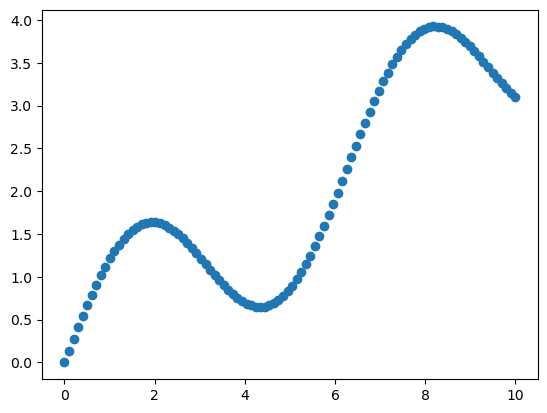

In [2]:
import numpy as np
import matplotlib.pyplot as plt
def sine_wave(x, angle=0):
    theta = np.radians(angle)
    return np.tan(theta)*x + np.sin(x)
X = np.linspace(0, 10, 100)
y = sine_wave(X, angle=20)
plt.scatter(X, y)

Don't get scared of the code above. Let's me explain.

I wanted to make a dataset with somewhat of a complex pattern. So, I'm using a `tilted sine wave` with angle 20 degrees.

For this I made the function `sine_wave`. This function represents the equation $y = \tan(\theta)x + \sin(x)$ where $\theta$ is the angle of the tangent line.

For, x values I'm taking 100 evenly spaced values between 0 and 10 using the `np.linspace()` function.

And now we padd the whole `x` to the `sine_wave` function and then we plot the `x` and `y` values.

And we see the dataset is generating almost a perfect squiggle. That goes up and down as the value of x rises.

My goal of this article is to show you if we can make a model that can predict this pattern.

One last thing I want to do to the dataset is add some randomness. 

The data looks too clean. Real life data is messy. These are generally refered to as **noisy data**.

So, I'll just add some noise to the $y$ values.

> Here, x is our feature and y is our target to predect.

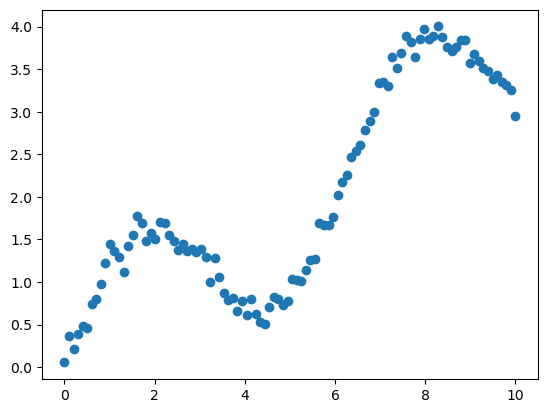

In [4]:
y = y + np.random.normal(loc=0, scale=0.1, size=X.shape)

plt.scatter(X, y)


Nice, now it looks like a real dataset.

We have `X` which is our feature and we have `y` which is our target.

So, now only one things left to do. We need to create a model.

# Steps in modelling a neural network

A neural netwrok model mainly has three parts.

1. **Input Layer**: This is the layer that takes in the input.
2. **Hidden Layers**: This is the layer that contains the hidden layers.
3. **Output Layer**: This is the layer that contains the output.

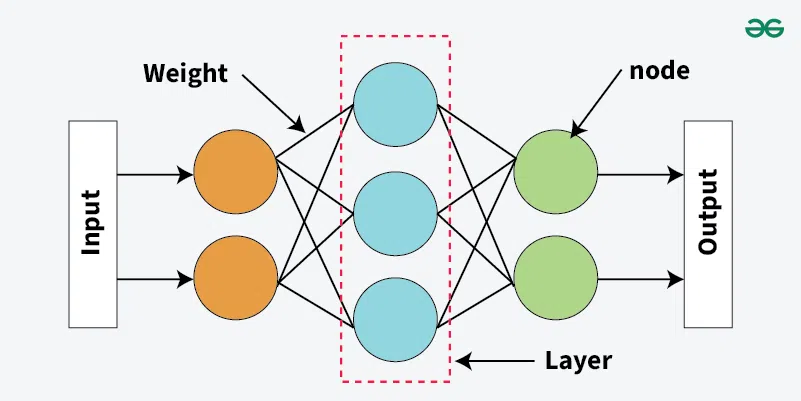

> To get e greater understanding of neural networks I heavily recommend watching [this](https://www.youtube.com/watch?v=CqOfi41LfDw)

First, let's make a input layer.

The input layer defines the input shape of each row in the data. As we only have one feature, the input shape will be 1.

Now, how do you find the shape of any row?

Simple, just take any index from the data and check the shape of that index using the `shape` function.

In [5]:
X.shape

(100,)

In [6]:
X[0].shape

()

If it's a empty bracket, then it's a scalar meaning there's only one value in that index.

> Scaler is 0-dimensional.

Which can be a issue because the input layer will expect at least one dimension.

So, I'll tranform the scalar to a 1-dimensional array using the `np.expand_dims()` function.

In [3]:
X_reshaped = np.expand_dims(X, axis=1)
X_reshaped.shape

(100, 1)

In [8]:
X_reshaped[0].shape

(1,)

Now, we can see the shape is (1,) which means it is a 1-dimensional array with one element.

Let's see if eveything is still the same of not.

In [9]:
X[:5], X_reshaped[:5]

(array([0.       , 0.1010101, 0.2020202, 0.3030303, 0.4040404]),
 array([[0.       ],
        [0.1010101],
        [0.2020202],
        [0.3030303],
        [0.4040404]]))

Yes! the values looks the same just now each value has it's one array.

Now, let's define a model.

In [9]:
from keras.models import Sequential

model = Sequential()

tf.keras.models.Sequential


Here, I'm defining a fully connected feed forward network using the `Sequential` class from the `keras` module.

Now, we can start adding layers to the model.

In [10]:
from keras.layers import Input

model.add(Input(shape=(1,)))

We can use `model.add()` to add layers to the model.

Now, to add the input layer we have to use `Input` function. This function will expect use to pass in the input shape as an argument.

So, as each row of the data has one feature, the input shape will be `(1,)`. So, just specify `(1,)` as the input shape.

Now, we make the hidden layers.

As we have a farely complex pattern, we might need multiple hidden layers, But first we should think about how many neurons should in the first hidden layer.

It's a common practice to use 2-4 times the number of features or multiple of 16 as the number of neurons in the first hidden layer.

We can choose any number of neurons if we want. Let's take 64.

In [ ]:
from tensorflow.keras.layers import Dense

model.add(
    Dense(
        units=64,
        activation='relu'
    )
)
tf.keras.layers.Dense

I0000 00:00:1785861061.347041  307079 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9637 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


There you go.

Let's break it down. To add a fully connected hidden layer we use the `Dense` class from the `keras` module.

This class will do most of heavy lifting for use. We just have to specify the number of neurons and the `activation function`.

What is a activation function?

An activation function is a function that is applied to the output of a layer. It is used to introduce `non-linearity` into the model.

> Learn more about activation functions [here](https://en.wikipedia.org/wiki/Activation_function)

There can be a lot of activation functions but the simplest and most common one is the `ReLU` activation function.

> Relu activation function is defined as `max(0, x)`. If the perceptron is less than 0, then the output is 0. If the perceptron is greater than 0, then the output is the same as the input.

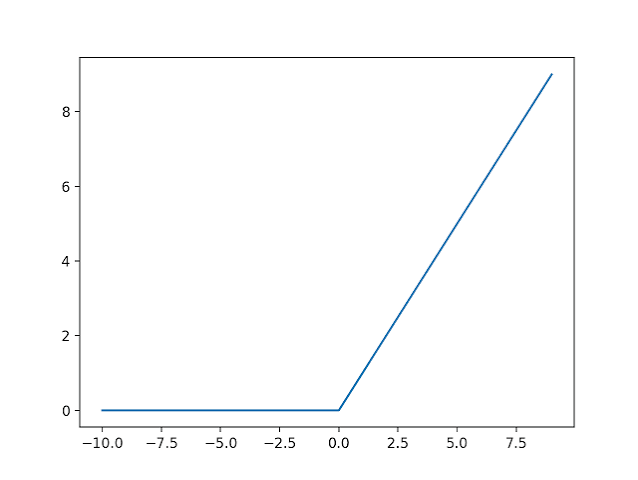


You can just write the name of the activation function as an argument in the `Dense` class.

Let's Add another one.


In [12]:
from tensorflow.keras.activations import relu

model.add(
    Dense(
        units=64,
        activation=relu
    )
)

A little side-quest for you guys. Try to figure out how you can pass other activation functions as an argument in the `Dense` class.

You can also pass `relu` as the activation function as an argument in dense class for better control and customization.

I'll keep it like this for now. Let's add the output layer.

As we are predicting a single continuous value we can directly use the `Dense` class with a single neuron. this neurons output will the final output of the model.

And we cannot put a activation in the output layer because if we do the final outcome will change which will be a problem.

In [13]:
model.add(
    Dense(units=1)
)

And trust me we are done. We've actually made a neural network model just like that.

Let's see how out model looks like.

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

Looking goooood.

This model has 4,353 Trainable parameters and ready to learn. So, time to tell it how to learn.

# Compiling the model

In [ ]:
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import MAE, MSE
from tensorflow.keras.metrics import MAE, MSE

model.compile(optimizer=Adam(learning_rate=0.0001), loss=MSE, metrics=[MAE, MSE])

Now we train.

In [63]:
model.fit(X, y, epochs=100, verbose=2)

Epoch 1/100


4/4 - 0s - 9ms/step - loss: 0.0084 - mean_absolute_error: 0.0751 - mean_squared_error: 0.0084
Epoch 2/100
4/4 - 0s - 8ms/step - loss: 0.0086 - mean_absolute_error: 0.0764 - mean_squared_error: 0.0086
Epoch 3/100
4/4 - 0s - 8ms/step - loss: 0.0086 - mean_absolute_error: 0.0763 - mean_squared_error: 0.0086
Epoch 4/100
4/4 - 0s - 7ms/step - loss: 0.0091 - mean_absolute_error: 0.0775 - mean_squared_error: 0.0091
Epoch 5/100
4/4 - 0s - 7ms/step - loss: 0.0091 - mean_absolute_error: 0.0774 - mean_squared_error: 0.0091
Epoch 6/100
4/4 - 0s - 7ms/step - loss: 0.0087 - mean_absolute_error: 0.0751 - mean_squared_error: 0.0087
Epoch 7/100
4/4 - 0s - 8ms/step - loss: 0.0086 - mean_absolute_error: 0.0744 - mean_squared_error: 0.0086
Epoch 8/100
4/4 - 0s - 7ms/step - loss: 0.0085 - mean_absolute_error: 0.0748 - mean_squared_error: 0.0085
Epoch 9/100
4/4 - 0s - 7ms/step - loss: 0.0085 - mean_absolute_error: 0.0750 - mean_squared_error: 0.0085
Epoch 10/100
4/4 - 0s - 7ms/step - loss: 0.0084 - mean_abs

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,061 (51.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,708 (34.02 KB)

In [75]:
predictions = model.predict(X)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


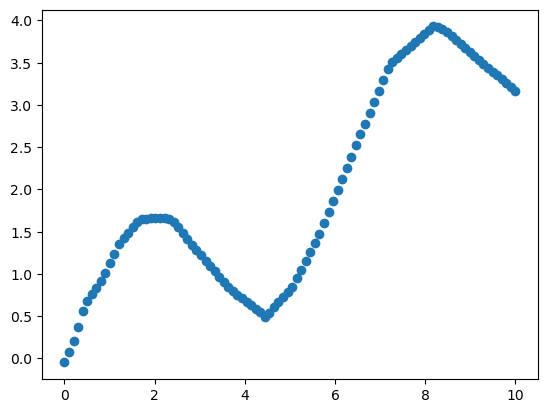

In [76]:
plt.scatter(X, predictions)

In [87]:
import tensorflow as tf
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [88]:
df = pd.read_csv('regres.csv')

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [90]:
df['Address'].unique()

array(['208 Michael Ferry Apt. 674\nLaurabury, NE 37010-5101',
       '188 Johnson Views Suite 079\nLake Kathleen, CA 48958',
       '9127 Elizabeth Stravenue\nDanieltown, WI 06482-3489', ...,
       '4215 Tracy Garden Suite 076\nJoshualand, VA 01707-9165',
       'USS Wallace\nFPO AE 73316',
       '37778 George Ridges Apt. 509\nEast Holly, NV 29290-3595'],
      dtype=object)

In [91]:
df.drop('Address', axis=1, inplace=True)

In [92]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


Here is a legitimate dataset. It has 5000 data points and i have imported using `pandas` library. 

this dataset has housing price in `USA` and we want to make a `deep learning model` that can predict the price of a house based on the features of the house.

Now how do we do that? We will use the same steps as we did with the simple dataset.

1. **Create a model**: define input and output layers, as well as the hidden layers.
2. **Compile the model**: define the loss function and the optimizer. `loss function` is used to calculate the error in the model and `optimizer` is used to minimize the error.
3. **Train the model**: train the model using the data.

But how do we do that? How do we create a model how many layers do we need? How many neurons do we need in each layer? What is the input shape? What is the output shape?

These are the questions that we need to answer before we can create a model.

We have the dataframe now let's now answere the questions.

1. **Input shape**: The input shape is the number of features in the dataset. In this dataset, we have 5 features. So, the input shape will be 5.
2. **Output shape**: The output shape is the number of outputs we want. In this dataset, we want to predict the price of the house. So, the output shape will be 1.
3. **Number of layers**: The number of layers is the number of hidden layers we want in the model. We can have as many layers as we want. But for this dataset, we will use 4 layers.
4. **Number of neurons in each layer**: The number of neurons in each layer is the number of neurons we want in each layer. But in the input layer, the number of neurons will be the input shape. In the output layer, the number of neurons will be the output shape. For the hidden layers, we can have as many neurons as we want. But for this dataset, we will use 128 neurons in each layer.

Now, we have the answers to all the questions. Let's create a model.

In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MSE, MAE
from tensorflow.keras.metrics import MSE, MAE
from tensorflow.keras.activations import relu,sigmoid


In [94]:
model = Sequential()
model.add(Dense(units=128, activation=relu))
model.add(Dense(units=64, activation=relu))
model.add(Dense(units=32, activation=relu))
model.add(Dense(units=16, activation=relu))
model.add(Dense(units=8, activation=relu))
model.add(Dense(units=1))

model.compile(optimizer=Adam(learning_rate=0.001), loss=MSE, metrics=[MAE])

In [95]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [96]:
X_train

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
2764,75012.341660,6.742828,6.604335,4.10,42877.424147
4904,70885.420819,6.358747,7.250241,5.42,38627.301473
3392,64547.646921,6.515966,4.626054,3.42,37084.665862
2575,65244.876417,7.729031,7.009954,6.03,39757.704309
4829,70365.514512,6.578554,7.383853,4.17,29450.530488
...,...,...,...,...,...
4905,94805.338639,6.271926,4.839427,4.49,45481.452601
3127,76611.889322,5.447756,8.570526,5.22,33001.914666
4699,45286.426303,5.591471,6.547357,2.30,45127.831887
4518,69017.581246,5.593646,6.504091,4.37,27751.985132


In [97]:
model.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=100, verbose=1)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1512244903936.0000 - mean_absolute_error: 1158637.2500
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63160139776.0000 - mean_absolute_error: 202493.8125
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63627878400.0000 - mean_absolute_error: 201575.5781
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62896717824.0000 - mean_absolute_error: 199033.5000
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62427865088.0000 - mean_absolute_error: 201499.8125
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62580465664.0000 - mean_absolute_error: 199844.9219
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 61375987712.0000 - mean_absolute_error: 197971.5000
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62008541184.0000 - mean_absolute_error: 201046.0312
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63256907776.0000 - mean_absolute

In [98]:
model.evaluate(X_test.to_numpy(), y_test.to_numpy())

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 64384303104.0000 - mean_absolute_error: 203405.1094  


[62999031808.0, 202726.375]

In [99]:
#make a bigger dataset
X = tf.range(-100, 100, 4)
y = X/2

In [100]:
X.numpy()

array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)

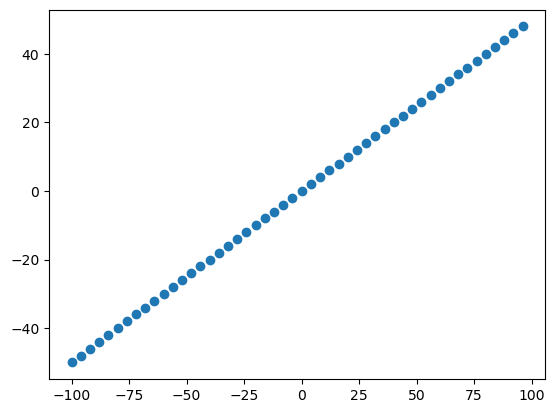

In [101]:
plt.scatter(X, y)

In [102]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X.numpy(), y.numpy(), test_size=0.2)

X_train, X_test, y_train, y_test = map(tf.constant, [X_train, X_test, y_train, y_test])

X_train, y_train, X_test, y_test

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([  60,  -24,  -48,   48,  -60, -100,   76,  -40,   96,  -80,  -68,
         -36,   40,   -8,    4,  -28,   52,  -12,  -32,  -84,   12,   28,
         -76,   36,  -20,    8,   64,   24,   72,  -96,   92,   16,  -64,
          88,   80,   56,   84,  -16,  -44,  -72], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=float64, numpy=
 array([ 30., -12., -24.,  24., -30., -50.,  38., -20.,  48., -40., -34.,
        -18.,  20.,  -4.,   2., -14.,  26.,  -6., -16., -42.,   6.,  14.,
        -38.,  18., -10.,   4.,  32.,  12.,  36., -48.,  46.,   8., -32.,
         44.,  40.,  28.,  42.,  -8., -22., -36.])>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ -4,  32, -56,  20,  44, -88,  68, -52, -92,   0], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=float64, numpy=array([ -2.,  16., -28.,  10.,  22., -44.,  34., -26., -46.,   0.])>)

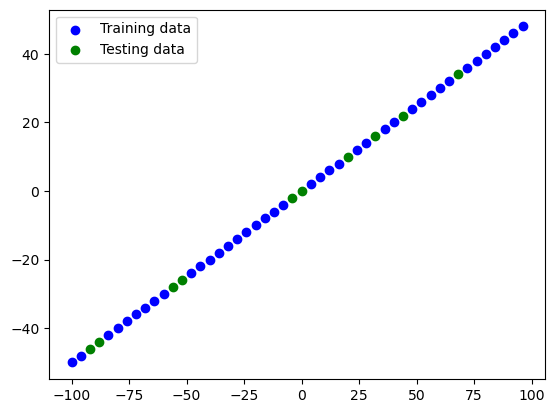

In [103]:
plt.scatter(X_train, y_train, c='b', label='Training data')
plt.scatter(X_test, y_test, c='g', label='Testing data')
plt.legend()

In [104]:
model = Sequential([
    Dense(1),
])

model.compile(optimizer=SGD(), loss=MSE, metrics=[MAE])

# model.fit(X_train, y_train, epochs=100, verbose=2)

In [105]:
model.build()

In [106]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [107]:
model = Sequential([
    Dense(10, input_shape=[1], name='input_layer', activation='relu'),
    Dense(1, name='output_layer')
])

model.compile(optimizer=Adam(), loss=MSE, metrics=[MAE])

model.build()

In [108]:
model.summary(include_config=True)


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/rishat/miniconda3/envs/ML_ENV/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_2263884/4251891141.py", line 1, in <module>
    model.summary(include_config=True)
  File "/home/rishat/miniconda3/envs/ML_ENV/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "/home/rishat/miniconda3/envs/ML_ENV/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 119, in error_handler
    filtered_tb = _process_traceback_frames(e.__traceback__)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: Model.summary() got an unexpected keyword argument 'include_config'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/rishat/miniconda3/envs/ML_ENV/

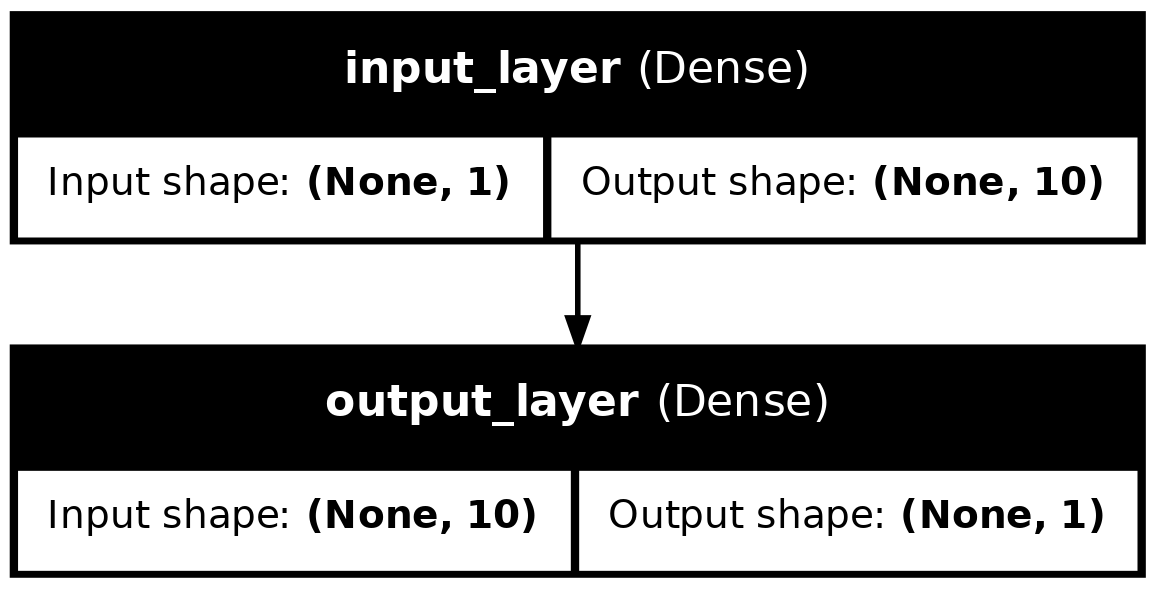

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
model.fit(X_train, y_train, epochs=100, verbose=2)

Epoch 1/100
2/2 - 0s - 22ms/step - loss: 0.1933 - mean_absolute_error: 0.2684
Epoch 2/100
2/2 - 0s - 19ms/step - loss: 0.1866 - mean_absolute_error: 0.2641
Epoch 3/100
2/2 - 0s - 28ms/step - loss: 0.1805 - mean_absolute_error: 0.2605
Epoch 4/100
2/2 - 0s - 15ms/step - loss: 0.1756 - mean_absolute_error: 0.2567
Epoch 5/100
2/2 - 0s - 30ms/step - loss: 0.1699 - mean_absolute_error: 0.2528
Epoch 6/100
2/2 - 0s - 15ms/step - loss: 0.1644 - mean_absolute_error: 0.2492
Epoch 7/100
2/2 - 0s - 17ms/step - loss: 0.1599 - mean_absolute_error: 0.2455
Epoch 8/100
2/2 - 0s - 19ms/step - loss: 0.1553 - mean_absolute_error: 0.2423
Epoch 9/100
2/2 - 0s - 26ms/step - loss: 0.1503 - mean_absolute_error: 0.2387
Epoch 10/100
2/2 - 0s - 16ms/step - loss: 0.1465 - mean_absolute_error: 0.2361
Epoch 11/100
2/2 - 0s - 15ms/step - loss: 0.1415 - mean_absolute_error: 0.2325
Epoch 12/100
2/2 - 0s - 16ms/step - loss: 0.1376 - mean_absolute_error: 0.2296
Epoch 13/100
2/2 - 0s - 20ms/step - loss: 0.1335 - mean_absol

In [ ]:
prediction = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [ ]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=prediction):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c='b', label='Training data')
    plt.scatter(test_data, test_labels, c='g', label='Testing data')
    plt.scatter(test_data, predictions, c='r', label='Predictions')
    plt.legend()

In [ ]:
model.evaluate(X_test, y_test, return_dict=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0464 - mean_absolute_error: 0.1267


{'loss': 0.0464211106300354, 'mean_absolute_error': 0.12670914828777313}

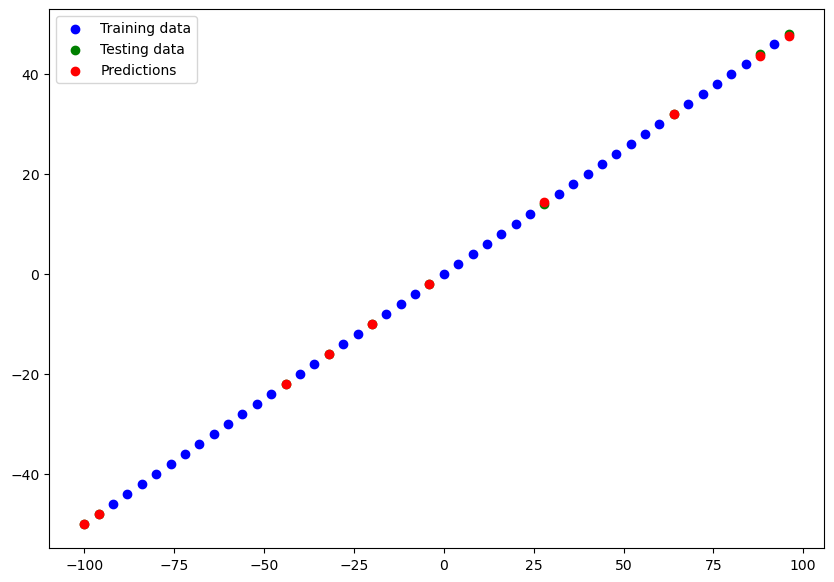

In [ ]:
plot_predictions( X_train, y_train, X_test, y_test, prediction)

In [ ]:
prediction.squeeze()

array([-16.00524  , -47.996407 ,  -2.0091007,  31.932232 ,  14.362276 ,
       -10.006894 ,  47.54997  ,  43.645535 , -22.003584 , -49.99586  ],
      dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=float64, numpy=array([-16., -48.,  -2.,  32.,  14., -10.,  48.,  44., -22., -50.])>

# Saving a model


There are two main format:
- Save model format
- HDF5 format

In [ ]:
model.save('model.keras')

In [ ]:
#loading the model
loaded_model = tf.keras.models.load_model('model.keras')

In [ ]:
loaded_predict = loaded_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


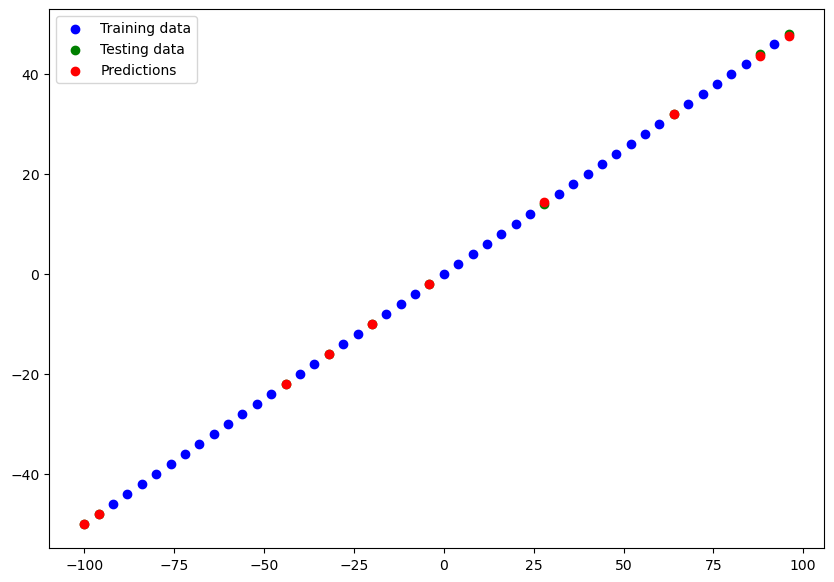

In [ ]:
plot_predictions(X_train, y_train, X_test, y_test, loaded_predict)